# 09b. Predicción a 50 m — Todos los modelos de la Sección 3

Notebook que lleva las predicciones de **todos los modelos areales** (Sección 3 del
libro) a resolución de **50 m** sobre la zona de estudio completa, evaluándolos
contra el raster real de Altiplanos.

**Estrategia (igual que `11_CAR_prediccion_total_v2`):**
1. Rasterizar la predicción/efecto de cada modelo areal (5 km) a 50 m.
2. Usar esa capa como **covariable adicional** en un modelo logístico a nivel de
   píxel: `Altiplano ~ Altitud + Pendiente + Relieve + Efecto_areal`.
3. Evaluar sobre los ~24,8M píxeles válidos del DEM.

**Modelos evaluados (12 areales + logístico base = 13 comparaciones):**
- 8 autorregresivos (NB09): OLS, SLX, SAR, SEM, SDM, SDEM, SAC, GNS
- 4 CAR/INLA (NB11): GLM, ICAR, BYM, Leroux

## 1. Configuración inicial

In [1]:
import os, time, warnings, sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.features import rasterize
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score, confusion_matrix,
                             roc_curve, ConfusionMatrixDisplay)
import statsmodels.api as sm
warnings.filterwarnings('ignore')

SEMILLA = 42
N_MUESTRA = 300_000
np.random.seed(SEMILLA)

BASE = r'C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial'
RASTER_DIR = os.path.join(BASE, 'Raster', '50m_UTM', 'Analisis')
RES_DIR = os.path.join(BASE, 'Resultados', '09b_prediccion_seccion3_50m_v2')
IMG_DIR = os.path.join(BASE, 'Imágenes', '09b_prediccion_seccion3_50m_v2')
os.makedirs(RES_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)
sys.path.insert(0, os.path.join(BASE, 'Codigo'))

print(f'SEMILLA = {SEMILLA}')
print(f'N_MUESTRA = {N_MUESTRA:,}')

SEMILLA = 42
N_MUESTRA = 300,000


## 2. Carga de rasters de referencia (50 m)

Se cargan los rasters originales a 50 m: DEM, pendiente, relieve y la capa
binaria de Altiplanos. La máscara de validez combina las tres capas topográficas.

In [2]:
t_inicio = time.time()

with rasterio.open(os.path.join(RASTER_DIR, 'DEM_NA_50.tif')) as src:
    altitud = src.read(1).astype(np.float32)
    dem_nodata = src.nodata
    ref_transform = src.transform
    ref_crs = src.crs
    ref_shape = (src.height, src.width)

with rasterio.open(os.path.join(RASTER_DIR, 'Slp_NA_50.tif')) as src:
    pendiente = src.read(1, out_shape=ref_shape).astype(np.float32)
    nodata_pend = src.nodata

with rasterio.open(os.path.join(RASTER_DIR, 'Rel_NA_5.tif')) as src:
    relieve = src.read(1, out_shape=ref_shape).astype(np.float32)
    nodata_rel = src.nodata

with rasterio.open(os.path.join(RASTER_DIR, 'Altiplanos.tif')) as src:
    altiplano_raw = src.read(1)
    alt_nodata = src.nodata
    alt_transform = src.transform
    alt_crs = src.crs

altiplano = np.zeros(ref_shape, dtype=np.uint8)
reproject(source=altiplano_raw, destination=altiplano,
          src_transform=alt_transform, src_crs=alt_crs,
          dst_transform=ref_transform, dst_crs=ref_crs,
          resampling=Resampling.nearest, src_nodata=alt_nodata, dst_nodata=0)

mascara = (altitud != dem_nodata) & (pendiente != nodata_pend) & (relieve != nodata_rel)
y_mapa = (altiplano == 1) & mascara
n_val = mascara.sum()
n_alt = y_mapa.sum()
filas, cols = np.where(mascara)
izq, abj, der, arr = array_bounds(ref_shape[0], ref_shape[1], ref_transform)

print(f'Grilla: {ref_shape} | Validos: {n_val:,} ({100*n_val/mascara.size:.1f}%)')
print(f'Altiplano=1: {n_alt:,} ({100*n_alt/n_val:.1f}%)')
print(f'Area valida: {n_val * abs(ref_transform.a)**2 / 1e6:,.0f} km2')

Grilla: (8276, 6084) | Validos: 24,783,966 (49.2%)
Altiplano=1: 3,746,338 (15.1%)
Area valida: 61,960 km2


## 3. Exploración de datos

=== Estadísticas descriptivas (submuestra 200k) ===
         Altitud  Pendiente    Relieve  Altiplano
count  200000.00  200000.00  200000.00  200000.00
mean     1235.42      18.63     153.18       0.15
std       765.41       9.85      80.33       0.36
min        19.00       0.00       0.00       0.00
25%       599.00      10.97      90.00       0.00
50%      1056.00      17.73     140.00       0.00
75%      1815.00      25.45     204.00       0.00
max      3849.00      84.81    2098.00       1.00


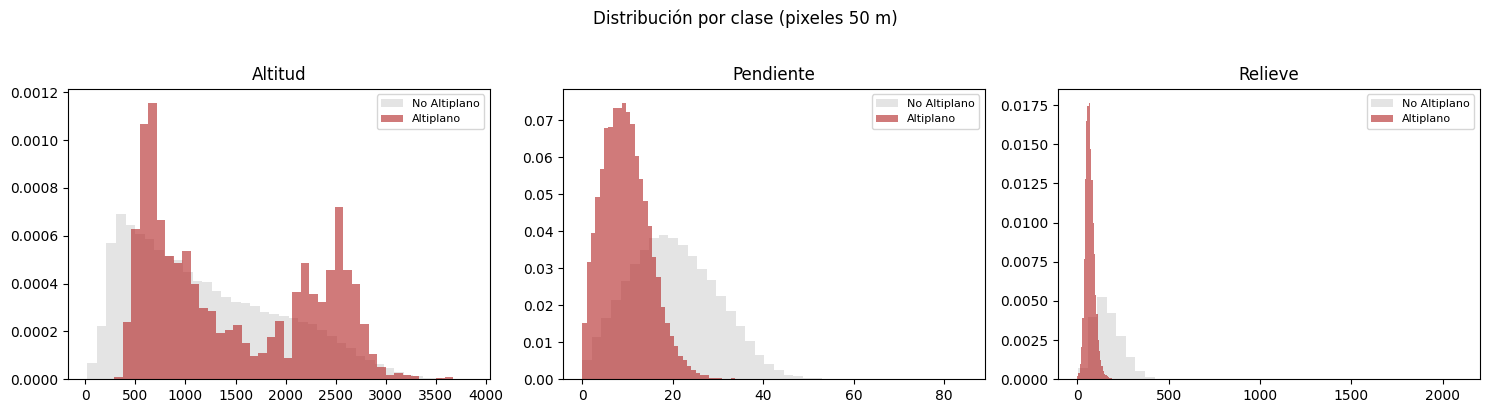


Proporción Altiplano: 15.1% (3,746,338 de 24,783,966)


In [3]:
idx_hist = np.random.choice(len(filas), size=200_000, replace=False)
fh, ch = filas[idx_hist], cols[idx_hist]

print('=== Estadísticas descriptivas (submuestra 200k) ===')
df_desc = pd.DataFrame({
    'Altitud': altitud[fh, ch], 'Pendiente': pendiente[fh, ch],
    'Relieve': relieve[fh, ch], 'Altiplano': y_mapa[fh, ch].astype(int)
})
print(df_desc.describe().round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Altitud', 'Pendiente', 'Relieve']):
    for cls, color, label in [(0, 'lightgray', 'No Altiplano'), (1, 'firebrick', 'Altiplano')]:
        sub = df_desc[df_desc['Altiplano'] == cls][col]
        ax.hist(sub, bins=40, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(col); ax.legend(fontsize=8)
plt.suptitle('Distribución por clase (pixeles 50 m)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, '00_histogramas.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nProporción Altiplano: {n_alt/n_val*100:.1f}% ({n_alt:,} de {n_val:,})')

## 4. Carga y rasterización de predicciones areales (5 km → 50 m)

Se cargan los GeoPackages de NB09 (autorregresivos) y NB11 (CAR/INLA).
Para cada modelo, se rasteriza su predicción de probabilidad a 50 m: cada
píxel recibe el valor de la celda de 5 km que lo contiene.

Para los modelos CAR (ICAR, BYM, Leroux), se rasteriza además el **efecto
espacial φ** (más principled que la probabilidad, ya que separa el componente
espacial del fijo).

In [4]:
# --- Cargar GeoPackages ---
gdf_ar = gpd.read_file(os.path.join(BASE, 'Resultados', 'autorregresivos_areales_v2.gpkg'))
gdf_car = gpd.read_file(os.path.join(BASE, 'Resultados', 'car_inla_comparacion_v2.gpkg'))
print(f'Autorregresivos: {len(gdf_ar)} celdas, cols={list(gdf_ar.columns)}')
print(f'CAR/INLA: {len(gdf_car)} celdas, cols={list(gdf_car.columns)}')

# --- Definir modelos a rasterizar ---
modelos_ar = [
    ('OLS', gdf_ar, 'prob_ols', None),
    ('SLX', gdf_ar, 'prob_slx', None),
    ('SAR', gdf_ar, 'prob_sar', None),
    ('SEM', gdf_ar, 'prob_sem', None),
    ('SDM (Durbin)', gdf_ar, 'prob_sdm', None),
    ('SDEM', gdf_ar, 'prob_sdem', None),
    ('SAC (SARAR)', gdf_ar, 'prob_sac', None),
    ('GNS', gdf_ar, 'prob_gns', None),
]

modelos_car = [
    ('GLM (INLA)', gdf_car, 'prob_glm', None),
    ('ICAR', gdf_car, 'prob_icar', 'phi_icar'),
    ('BYM', gdf_car, 'prob_bym', 'phi_bym_s'),
    ('Leroux', gdf_car, 'prob_ler', 'phi_leroux'),
]

todos_modelos = modelos_ar + modelos_car

# --- Rasterizar cada modelo ---
t0 = time.time()
rasters_prob = {}
rasters_phi = {}

for nombre, gdf, col_prob, col_phi in todos_modelos:
    shapes_prob = [(geom, val) for geom, val in zip(gdf.geometry, gdf[col_prob])]
    rasters_prob[nombre] = rasterize(shapes_prob, out_shape=ref_shape,
                                      transform=ref_transform, fill=np.nan,
                                      dtype='float32')
    if col_phi is not None:
        shapes_phi = [(geom, val) for geom, val in zip(gdf.geometry, gdf[col_phi])]
        rasters_phi[nombre] = rasterize(shapes_phi, out_shape=ref_shape,
                                         transform=ref_transform, fill=0.0,
                                         dtype='float32')

print(f'Rasterización completada en {time.time()-t0:.1f}s')
print(f'  Probabilidades rasterizadas: {len(rasters_prob)}')
print(f'  Efectos espaciales (phi): {len(rasters_phi)} ({list(rasters_phi.keys())})')

# Verificar cobertura
for nombre in rasters_prob:
    r = rasters_prob[nombre]
    cob = np.isfinite(r[mascara]).sum()
    print(f'  {nombre}: {cob:,} pixeles con prediccion ({100*cob/n_val:.1f}%)')

Autorregresivos: 2596 celdas, cols=['y', 'altitud', 'pendiente', 'relieve', 'region', 'prob_ols', 'prob_slx', 'prob_sar', 'prob_sem', 'prob_sdm', 'prob_sdem', 'prob_sac', 'prob_gns', 'pred_best', 'modelo_best', 'geometry']
CAR/INLA: 2596 celdas, cols=['y', 'altitud', 'pendiente', 'relieve', 'region', 'prob_glm', 'prob_icar', 'prob_bym', 'prob_ler', 'phi_icar', 'phi_bym_s', 'phi_bym_i', 'phi_leroux', 'pred_best', 'geometry']


Rasterización completada en 3.4s
  Probabilidades rasterizadas: 12
  Efectos espaciales (phi): 3 (['ICAR', 'BYM', 'Leroux'])
  OLS: 24,701,712 pixeles con prediccion (99.7%)
  SLX: 24,701,712 pixeles con prediccion (99.7%)


  SAR: 24,701,712 pixeles con prediccion (99.7%)
  SEM: 24,701,712 pixeles con prediccion (99.7%)
  SDM (Durbin): 24,701,712 pixeles con prediccion (99.7%)


  SDEM: 24,701,712 pixeles con prediccion (99.7%)
  SAC (SARAR): 24,701,712 pixeles con prediccion (99.7%)
  GNS: 24,701,712 pixeles con prediccion (99.7%)


  GLM (INLA): 24,701,712 pixeles con prediccion (99.7%)
  ICAR: 24,701,712 pixeles con prediccion (99.7%)
  BYM: 24,701,712 pixeles con prediccion (99.7%)


  Leroux: 24,701,712 pixeles con prediccion (99.7%)


## 5. Modelos logísticos a nivel de píxel

Para cada modelo areal, se entrena un logístico a 50 m con la forma:

`Altiplano ~ Altitud + Pendiente + Relieve + Efecto_areal`

donde `Efecto_areal` es:
- Para autorregresivos y GLM: la **probabilidad rasterizada** del modelo a 5 km
- Para ICAR/BYM/Leroux: el **efecto espacial φ** (componente puramente espacial)

Esto combina el prior espacial del modelo areal con el detalle topográfico a 50 m.
Muestra de entrenamiento: 300.000 píxeles (SEMILLA=42).

In [5]:
# Muestra de entrenamiento
idx_muestra = np.random.choice(len(filas), size=N_MUESTRA, replace=False)
fs, cs = filas[idx_muestra], cols[idx_muestra]
y_sample = y_mapa[fs, cs].astype(int)

# Covariables base (sin efecto areal)
X_base_raw = np.column_stack([altitud[fs, cs], pendiente[fs, cs], relieve[fs, cs]])
scaler_base = StandardScaler()
X_base_std = scaler_base.fit_transform(X_base_raw)
modelo_base = sm.Logit(y_sample, sm.add_constant(X_base_std)).fit(disp=0)
print(f'Logístico base: Pseudo R2={modelo_base.prsquared:.4f}, AIC={modelo_base.aic:.0f}')

# Entrenar un modelo pixel-enhanced para cada modelo areal
resultados_pixel = []
scalers = {}
modelos_px = {}

for nombre, gdf, col_prob, col_phi in todos_modelos:
    # Elegir el efecto: phi si existe (CAR), prob si no (autorregresivos)
    if col_phi and nombre in rasters_phi:
        efecto = rasters_phi[nombre][fs, cs]
        tipo_efecto = 'phi'
    else:
        efecto = rasters_prob[nombre][fs, cs]
        tipo_efecto = 'prob'

    # Verificar que no hay NaN en la muestra
    valid = np.isfinite(efecto)
    if valid.sum() < N_MUESTRA * 0.9:
        print(f'  {nombre}: solo {valid.sum():,} válidos — saltar')
        continue

    X_px = np.column_stack([altitud[fs, cs], pendiente[fs, cs], relieve[fs, cs], efecto])
    X_px = X_px[valid]
    y_px = y_sample[valid]

    scaler = StandardScaler()
    X_px_std = scaler.fit_transform(X_px)
    modelo = sm.Logit(y_px, sm.add_constant(X_px_std)).fit(disp=0)

    scalers[nombre] = scaler
    modelos_px[nombre] = modelo

    print(f'  {nombre} ({tipo_efecto}): Pseudo R2={modelo.prsquared:.4f}, '
          f'AIC={modelo.aic:.0f}, coef_{tipo_efecto}={modelo.params[-1]:.3f}')

# Guardar Pseudo R2 y AIC de cada modelo para la tabla final
prsquared = {nombre: modelos_px[nombre].prsquared for nombre in modelos_px}
prsquared['Logístico base'] = modelo_base.prsquared
aic_px = {nombre: modelos_px[nombre].aic for nombre in modelos_px}
aic_px['Logístico base'] = modelo_base.aic

print(f'\nModelos pixel entrenados: {len(modelos_px)}')

Logístico base: Pseudo R2=0.4829, AIC=131732


  OLS (prob): Pseudo R2=0.5245, AIC=120975, coef_prob=1.098


  SLX (prob): Pseudo R2=0.5265, AIC=120484, coef_prob=1.114


  SAR (prob): Pseudo R2=0.5924, AIC=103711, coef_prob=1.369


  SEM (prob): Pseudo R2=0.5193, AIC=122309, coef_prob=1.028


...

  GNS (prob): Pseudo R2=0.5892, AIC=104518, coef_prob=1.015


  GLM (INLA) (prob): Pseudo R2=0.5546, AIC=113341, coef_prob=0.989


  ICAR (phi): Pseudo R2=0.6249, AIC=95574, coef_phi=2.182


  BYM (phi): Pseudo R2=0.6237, AIC=95872, coef_phi=2.152


  Leroux (phi): Pseudo R2=0.6528, AIC=88468, coef_phi=1.819

Modelos pixel entrenados: 12


## 6. Predicción sobre todo el DEM (24,8M píxeles)

In [6]:
CHUNK = 500_000
prob_base_full = np.full(ref_shape, np.nan, dtype=np.float32)
prob_pixel_full = {}

# Predicción base
t0 = time.time()
for i in range(0, len(filas), CHUNK):
    sl = slice(i, min(i + CHUNK, len(filas)))
    fi, ci = filas[sl], cols[sl]
    xb = scaler_base.transform(np.column_stack([altitud[fi, ci], pendiente[fi, ci], relieve[fi, ci]]))
    prob_base_full[fi, ci] = modelo_base.predict(sm.add_constant(xb))
print(f'Base: {time.time()-t0:.1f}s')

# Predicción pixel-enhanced para cada modelo
for nombre in modelos_px:
    prob_pixel_full[nombre] = np.full(ref_shape, np.nan, dtype=np.float32)
    if nombre in rasters_phi:
        efecto_full = rasters_phi[nombre]
    else:
        efecto_full = rasters_prob[nombre]

    t0 = time.time()
    for i in range(0, len(filas), CHUNK):
        sl = slice(i, min(i + CHUNK, len(filas)))
        fi, ci = filas[sl], cols[sl]
        ef = efecto_full[fi, ci]
        valid = np.isfinite(ef)
        if valid.sum() == 0:
            continue
        fi_v, ci_v = fi[valid], ci[valid]
        xp = scalers[nombre].transform(np.column_stack([
            altitud[fi_v, ci_v], pendiente[fi_v, ci_v],
            relieve[fi_v, ci_v], ef[valid]]))
        prob_pixel_full[nombre][fi_v, ci_v] = modelos_px[nombre].predict(sm.add_constant(xp))
    print(f'  {nombre}: {time.time()-t0:.1f}s')

print(f'\nPredicción completa sobre {len(filas):,} píxeles')

Base: 2.7s


  OLS: 3.1s


  SLX: 3.1s


  SAR: 3.2s


  SEM: 3.1s


...

  GNS: 3.1s


  GLM (INLA): 3.2s


  ICAR: 3.2s


  BYM: 3.2s


  Leroux: 3.2s

Predicción completa sobre 24,783,966 píxeles


## 7. Evaluación de métricas (todos los píxeles válidos)

Se calculan AUC-ROC, Accuracy, F1, Precision y Recall sobre los ~24,8M píxeles
válidos. Se comparan tres versiones de cada modelo:
1. **Directo (5 km):** la probabilidad rasterizada del modelo areal, sin pixel-enhancement
2. **Pixel-enhanced:** logístico a 50 m con el efecto areal como covariable
3. **Logístico base:** referencia sin ningún efecto areal

In [7]:
y_all = y_mapa[mascara].astype(int)
pb = prob_base_full[mascara]

def calc_metricas(y, p, nombre, tipo=''):
    mask = np.isfinite(p)
    if mask.sum() < len(y) * 0.5:
        return None
    y_v, p_v = y[mask], p[mask]
    pred = (p_v >= 0.5).astype(int)
    return {
        'Modelo': nombre, 'Tipo': tipo,
        'AUC': roc_auc_score(y_v, p_v),
        'Accuracy': accuracy_score(y_v, pred),
        'F1': f1_score(y_v, pred),
        'Precision': precision_score(y_v, pred),
        'Recall': recall_score(y_v, pred),
        'Pseudo_R2': prsquared.get(nombre, np.nan),
        'AIC': aic_px.get(nombre, np.nan),
        'N_pixeles': int(mask.sum()),
    }

resultados = []

# Logístico base
resultados.append(calc_metricas(y_all, pb, 'Logístico base', 'Referencia'))

# Cada modelo: directo + pixel-enhanced
for nombre in rasters_prob:
    # Directo (rasterización sin pixel-enhancement)
    p_dir = rasters_prob[nombre][mascara]
    r = calc_metricas(y_all, p_dir, nombre, 'Directo 5km')
    if r:
        r['Pseudo_R2'] = np.nan
        r['AIC'] = np.nan
        resultados.append(r)

    # Pixel-enhanced
    if nombre in prob_pixel_full:
        p_px = prob_pixel_full[nombre][mascara]
        r = calc_metricas(y_all, p_px, nombre, 'Pixel 50m')
        if r: resultados.append(r)

df_res = pd.DataFrame(resultados)
df_res = df_res.sort_values('AUC', ascending=False).reset_index(drop=True)

print('=' * 120)
print('  COMPARACIÓN DE TODOS LOS MODELOS — Sección 3 evaluados a 50 m')
print('=' * 120)
print(df_res.to_string(index=False, float_format=lambda x: f'{x:.4f}' if abs(x) < 10 else f'{x:.0f}'))

# Guardar
df_res.to_csv(os.path.join(RES_DIR, 'metricas_seccion3_50m.csv'), index=False)
print(f'\nMétricas guardadas')

# Resumen
best_px = df_res[df_res['Tipo'] == 'Pixel 50m'].iloc[0]
best_dir = df_res[df_res['Tipo'] == 'Directo 5km'].iloc[0]
print(f'\nMejor pixel-enhanced: {best_px["Modelo"]} (AUC={best_px["AUC"]:.4f})')
print(f'Mejor directo: {best_dir["Modelo"]} (AUC={best_dir["AUC"]:.4f})')
print(f'Logístico base: AUC={df_res[df_res["Tipo"]=="Referencia"].iloc[0]["AUC"]:.4f}')

  COMPARACIÓN DE TODOS LOS MODELOS — Sección 3 evaluados a 50 m
        Modelo        Tipo    AUC  Accuracy     F1  Precision  Recall  Pseudo_R2    AIC  N_pixeles
        Leroux   Pixel 50m 0.9729    0.9382 0.7906     0.8107  0.7716     0.6528  88468   24783966
          ICAR   Pixel 50m 0.9683    0.9330 0.7711     0.7975  0.7464     0.6249  95574   24783966
           BYM   Pixel 50m 0.9681    0.9328 0.7702     0.7970  0.7452     0.6237  95872   24783966
  SDM (Durbin)   Pixel 50m 0.9626    0.9253 0.7391     0.7857  0.6977     0.6000 101781   24701712
           SAR   Pixel 50m 0.9611    0.9237 0.7324     0.7822  0.6885     0.5924 103711   24701712
           GNS   Pixel 50m 0.9603    0.9254 0.7378     0.7902  0.6919     0.5892 104518   24701712
   SAC (SARAR)   Pixel 50m 0.9534    0.9162 0.7020     0.7615  0.6511     0.5565 112859   24701712
    GLM (INLA)   Pixel 50m 0.9531    0.9161 0.7044     0.7567  0.6589     0.5546 113341   24701712
           SLX   Pixel 50m 0.9470    0.9084 0

### Curvas ROC — Mejores modelos

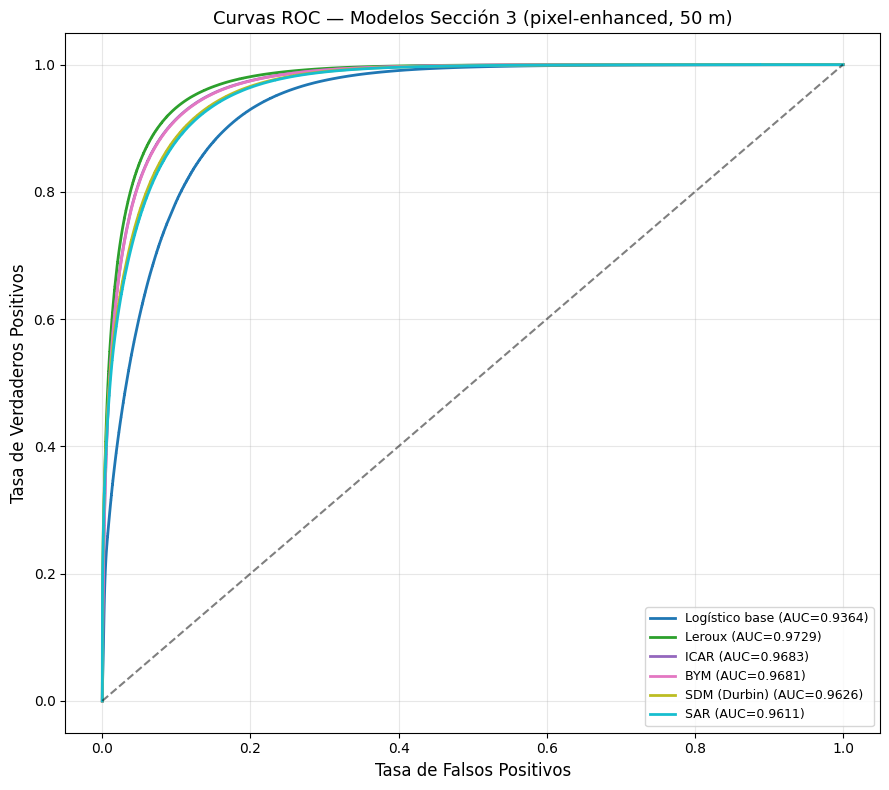

In [8]:
# Top modelos para la ROC (no graficar los 24)
modelos_roc = ['Logístico base']
# Agregar los mejores pixel-enhanced
df_px = df_res[df_res['Tipo'] == 'Pixel 50m'].head(5)
modelos_roc += df_px['Modelo'].tolist()

fig, ax = plt.subplots(figsize=(9, 8))
colores = plt.cm.tab10(np.linspace(0, 1, len(modelos_roc)))

for (nombre, color) in zip(modelos_roc, colores):
    if nombre == 'Logístico base':
        p = pb
        y_roc = y_all
    else:
        p = prob_pixel_full[nombre][mascara]
        y_roc = y_all
    mask = np.isfinite(p)
    fpr, tpr, _ = roc_curve(y_roc[mask], p[mask], pos_label=1)
    auc = roc_auc_score(y_roc[mask], p[mask])
    label = f'{nombre} (AUC={auc:.4f})'
    ax.plot(fpr, tpr, color=color, linewidth=2, label=label)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
ax.set_title('Curvas ROC — Modelos Sección 3 (pixel-enhanced, 50 m)', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, '01_curvas_roc_50m.png'), dpi=150, bbox_inches='tight')
plt.show()

### Comparación Directo vs Pixel-enhanced

Comparación Directo (5 km) vs Pixel-enhanced (50 m):
      Modelo  AUC_directo  AUC_pixel  Mejora
      Leroux       0.9400     0.9729  0.0330
        ICAR       0.9374     0.9683  0.0309
         BYM       0.9374     0.9681  0.0307
SDM (Durbin)       0.9261     0.9626  0.0365
         SAR       0.9229     0.9611  0.0382
         GNS       0.8375     0.9603  0.1228
 SAC (SARAR)       0.9106     0.9534  0.0428
  GLM (INLA)       0.9072     0.9531  0.0459
         SLX       0.8919     0.9470  0.0551
         OLS       0.8906     0.9466  0.0560
        SDEM       0.8898     0.9462  0.0564
         SEM       0.8857     0.9455  0.0598


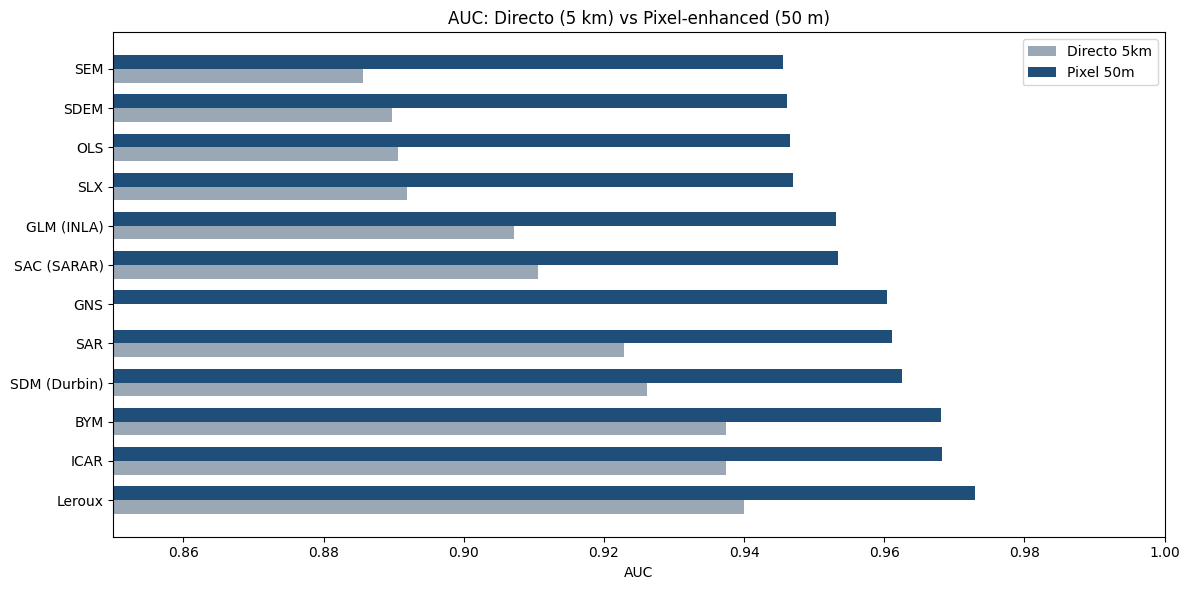

In [9]:
df_pivot = df_res[df_res['Tipo'].isin(['Directo 5km', 'Pixel 50m'])].copy()
df_dir = df_pivot[df_pivot['Tipo'] == 'Directo 5km'][['Modelo', 'AUC']].rename(columns={'AUC': 'AUC_directo'})
df_pix = df_pivot[df_pivot['Tipo'] == 'Pixel 50m'][['Modelo', 'AUC']].rename(columns={'AUC': 'AUC_pixel'})
df_comp = df_dir.merge(df_pix, on='Modelo')
df_comp['Mejora'] = df_comp['AUC_pixel'] - df_comp['AUC_directo']
df_comp = df_comp.sort_values('AUC_pixel', ascending=False)

print('Comparación Directo (5 km) vs Pixel-enhanced (50 m):')
print(df_comp.to_string(index=False, float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_comp))
ax.barh(x, df_comp['AUC_directo'].values, height=0.35, label='Directo 5km', color='#9aa7b4', align='center')
ax.barh([i + 0.35 for i in x], df_comp['AUC_pixel'].values, height=0.35,
        label='Pixel 50m', color='#1f4e79', align='center')
ax.set_yticks([i + 0.175 for i in x])
ax.set_yticklabels(df_comp['Modelo'].values)
ax.set_xlabel('AUC')
ax.set_title('AUC: Directo (5 km) vs Pixel-enhanced (50 m)')
ax.legend()
ax.set_xlim(0.85, 1.0)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, '02_comparacion_directo_vs_pixel.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Mapas de predicción — Mejores modelos

Mapas con plantilla cartográfica de los 3 mejores modelos pixel-enhanced
vs. el logístico base y el observado.

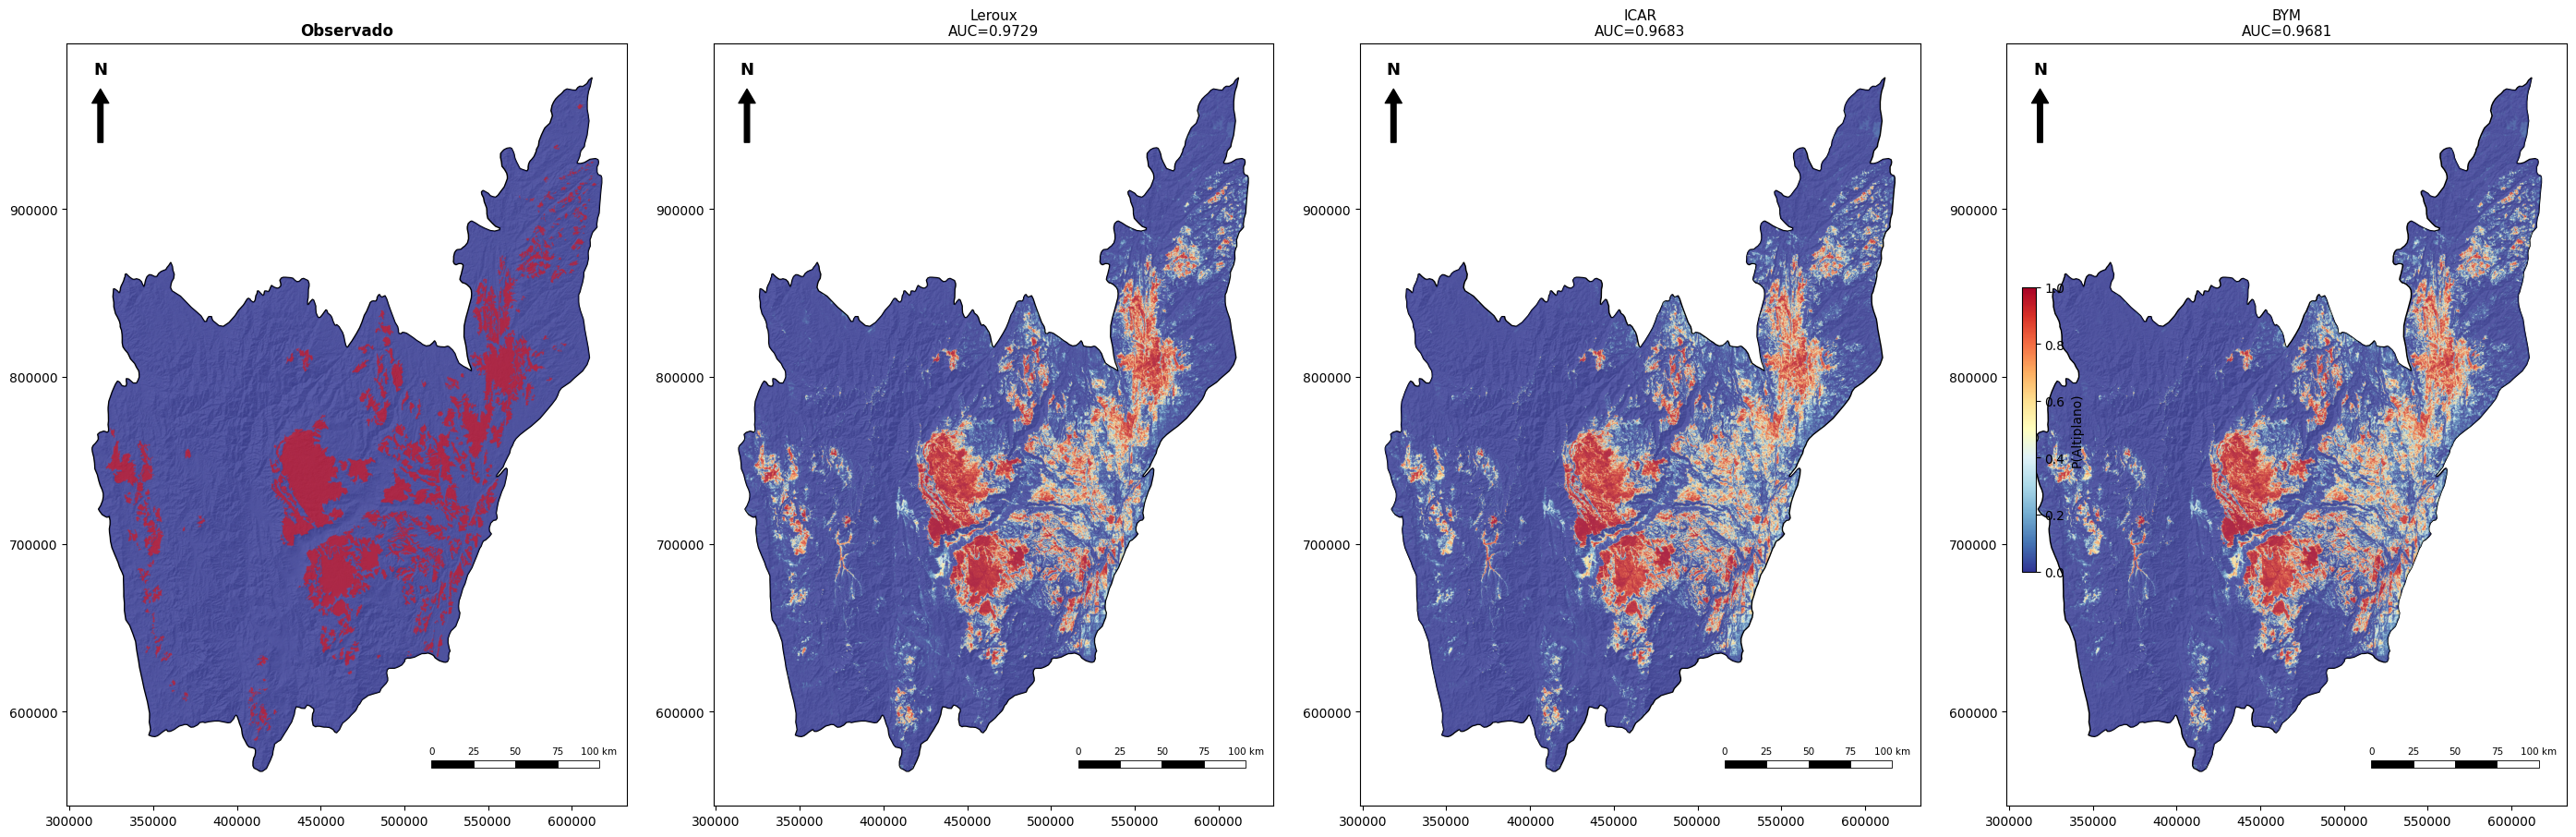

In [10]:
from plantilla_mapas import aplicar_plantilla_mapa

# Identificar los 3 mejores pixel-enhanced
top3 = df_res[df_res['Tipo'] == 'Pixel 50m'].head(3)['Modelo'].tolist()

fig, axes = plt.subplots(1, len(top3) + 1, figsize=(7 * (len(top3) + 1), 10))

# Observado
ax = axes[0]
aplicar_plantilla_mapa(ax)
im = ax.imshow(np.where(mascara, y_mapa.astype(float), np.nan),
               cmap='RdYlBu_r', vmin=0, vmax=1,
               extent=(izq, der, abj, arr), alpha=0.8, zorder=5)
ax.set_title('Observado', fontsize=12, fontweight='bold')

# Top 3 modelos
for i, nombre in enumerate(top3):
    ax = axes[i + 1]
    aplicar_plantilla_mapa(ax)
    auc_val = df_res[(df_res['Modelo'] == nombre) & (df_res['Tipo'] == 'Pixel 50m')]['AUC'].values[0]
    im = ax.imshow(prob_pixel_full[nombre], cmap='RdYlBu_r', vmin=0, vmax=1,
                   extent=(izq, der, abj, arr), alpha=0.8, zorder=5)
    ax.set_title(f'{nombre}\nAUC={auc_val:.4f}', fontsize=11)

sm_cb = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=plt.Normalize(0, 1))
sm_cb._A = []
fig.colorbar(sm_cb, ax=axes, shrink=0.4, label='P(Altiplano)', pad=0.02)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, '03_mapas_top3_plantilla.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(IMG_DIR, '03_mapas_top3_plantilla.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Exportación de resultados

In [11]:
# Exportar GeoTIFF del mejor modelo pixel-enhanced
best_name = df_res[df_res['Tipo'] == 'Pixel 50m'].iloc[0]['Modelo']
best_prob = prob_pixel_full[best_name]

perfil = {'driver': 'GTiff', 'height': ref_shape[0], 'width': ref_shape[1],
          'count': 1, 'dtype': 'float32', 'crs': ref_crs, 'transform': ref_transform,
          'nodata': np.nan, 'compress': 'lzw'}

out_path = os.path.join(BASE, 'Resultados', 'prediccion_seccion3_mejor_50m_v2.tif')
with rasterio.open(out_path, 'w', **perfil) as dst:
    dst.write(best_prob.astype(np.float32), 1)
print(f'GeoTIFF del mejor modelo ({best_name}): {out_path}')

# Exportar GeoTIFF de cada modelo pixel-enhanced (multibanda)
nombres_bandas = list(prob_pixel_full.keys())
perfil_multi = perfil.copy()
perfil_multi['count'] = len(nombres_bandas)
out_multi = os.path.join(BASE, 'Resultados', 'prediccion_seccion3_todos_50m_v2.tif')
with rasterio.open(out_multi, 'w', **perfil_multi) as dst:
    for i, nombre in enumerate(nombres_bandas):
        dst.write(prob_pixel_full[nombre].astype(np.float32), i + 1)
        dst.set_band_description(i + 1, nombre)
print(f'GeoTIFF multibanda ({len(nombres_bandas)} bandas): {out_multi}')

print(f'  Bandas: {nombres_bandas}')
print(f'  Resolución: {abs(ref_transform.a):.0f} m')
print(f'  Píxeles con predicción: {np.isfinite(best_prob).sum():,}')

GeoTIFF del mejor modelo (Leroux): C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\prediccion_seccion3_mejor_50m_v2.tif


GeoTIFF multibanda (12 bandas): C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\prediccion_seccion3_todos_50m_v2.tif
  Bandas: ['OLS', 'SLX', 'SAR', 'SEM', 'SDM (Durbin)', 'SDEM', 'SAC (SARAR)', 'GNS', 'GLM (INLA)', 'ICAR', 'BYM', 'Leroux']
  Resolución: 50 m
  Píxeles con predicción: 24,783,966


In [12]:
print('\n' + '=' * 100)
print('  RESUMEN FINAL — Modelos Sección 3 evaluados a 50 m')
print('=' * 100)

# Tabla solo pixel-enhanced + base
df_final = df_res[df_res['Tipo'].isin(['Referencia', 'Pixel 50m'])].copy()
df_final = df_final.sort_values('AUC', ascending=False)
cols = ['Modelo', 'AUC', 'Pseudo_R2', 'AIC', 'Accuracy', 'F1', 'Precision', 'Recall']
print(df_final[cols].to_string(index=False,
    float_format=lambda x: f'{x:.4f}' if abs(x) < 10 else f'{x:.0f}'))

best = df_final.iloc[0]
print(f'\nMejor modelo: {best["Modelo"]} — AUC={best["AUC"]:.4f}, F1={best["F1"]:.4f}')
print(f'Logístico base: AUC={df_final[df_final["Modelo"]=="Logístico base"].iloc[0]["AUC"]:.4f}')

print(f'\nArchivos generados:')
for f in sorted(os.listdir(RES_DIR)):
    fpath = os.path.join(RES_DIR, f)
    if os.path.isfile(fpath):
        print(f'  {f} ({os.path.getsize(fpath)/1024:.0f} KB)')
print(f'  prediccion_seccion3_mejor_50m_v2.tif')
print(f'  prediccion_seccion3_todos_50m_v2.tif')

print(f'\nTIEMPO TOTAL: {time.time()-t_inicio:.0f} s ({(time.time()-t_inicio)/60:.1f} min)')


  RESUMEN FINAL — Modelos Sección 3 evaluados a 50 m
        Modelo    AUC  Pseudo_R2    AIC  Accuracy     F1  Precision  Recall
        Leroux 0.9729     0.6528  88468    0.9382 0.7906     0.8107  0.7716
          ICAR 0.9683     0.6249  95574    0.9330 0.7711     0.7975  0.7464
           BYM 0.9681     0.6237  95872    0.9328 0.7702     0.7970  0.7452
  SDM (Durbin) 0.9626     0.6000 101781    0.9253 0.7391     0.7857  0.6977
           SAR 0.9611     0.5924 103711    0.9237 0.7324     0.7822  0.6885
           GNS 0.9603     0.5892 104518    0.9254 0.7378     0.7902  0.6919
   SAC (SARAR) 0.9534     0.5565 112859    0.9162 0.7020     0.7615  0.6511
    GLM (INLA) 0.9531     0.5546 113341    0.9161 0.7044     0.7567  0.6589
           SLX 0.9470     0.5265 120484    0.9084 0.6688     0.7400  0.6101
           OLS 0.9466     0.5245 120975    0.9081 0.6675     0.7393  0.6085
          SDEM 0.9462     0.5228 121424    0.9075 0.6652     0.7375  0.6058
           SEM 0.9455     0.5193 1